In [1]:
import pandas as pd

encoded_df = pd.read_csv("encoded_network_features.csv")

In [2]:
encoded_df.head()


,enc1,enc2,enc3,enc4,enc5,Label
0,0.0,2.115487,6.789456,1.784728,2.073033,0
1,0.0,3.316629,4.795515,2.762662,1.795068,0
2,0.0,3.223679,4.678621,2.714304,1.793723,0
3,0.0,3.232596,4.421460,2.842839,2.021290,0
4,0.0,2.115523,6.789395,1.784756,2.073121,0


In [ ]:
X = encoded_df.drop(columns=['Label'])
y = encoded_df['Label'] #SEPERATING LABELS

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    min_samples_split=5,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,150
,criterion,'gini'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[450572   3693]
 [  2176 109135]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    454265
           1       0.97      0.98      0.97    111311

    accuracy                           0.99    565576
   macro avg       0.98      0.99      0.98    565576
weighted avg       0.99      0.99      0.99    565576



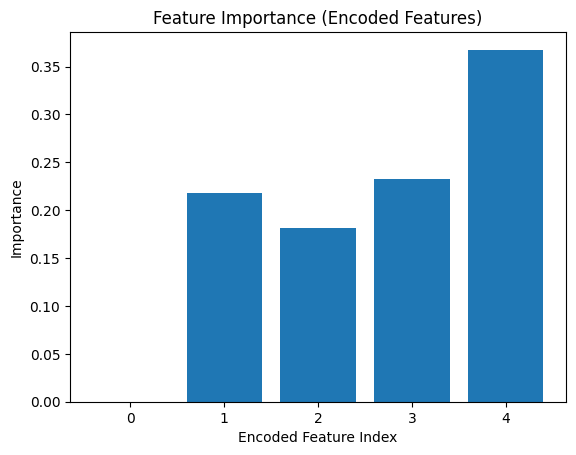

In [7]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_

plt.bar(range(len(importances)), importances)
plt.title("Feature Importance (Encoded Features)")
plt.xlabel("Encoded Feature Index")
plt.ylabel("Importance")
plt.show()

In [9]:
y_train_pred = rf.predict(X_train)

print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1817055
           1       0.97      0.99      0.98    445245

    accuracy                           0.99   2262300
   macro avg       0.98      0.99      0.99   2262300
weighted avg       0.99      0.99      0.99   2262300



In [10]:
import joblib

joblib.dump(rf, "rf_model.pkl")

['rf_model.pkl']

In [11]:
joblib.dump(list(X.columns), "feature_columns.pkl") 

['feature_columns.pkl']